# Figure 5 - Receptive Fields

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py
import scipy

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [87]:
figure_name = "Fig5_receptive_fields"
model_list = ["vanBP", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

population = 'H2E'

Generating plots for Feedforward ANN, population: H2E
Generating plots for Backprop 
(fixed SomaI), population: H2E
Generating plots for Hebbian, population: H2E
Generating plots for Dendritic Target 
Propagation (LDS), population: H2E


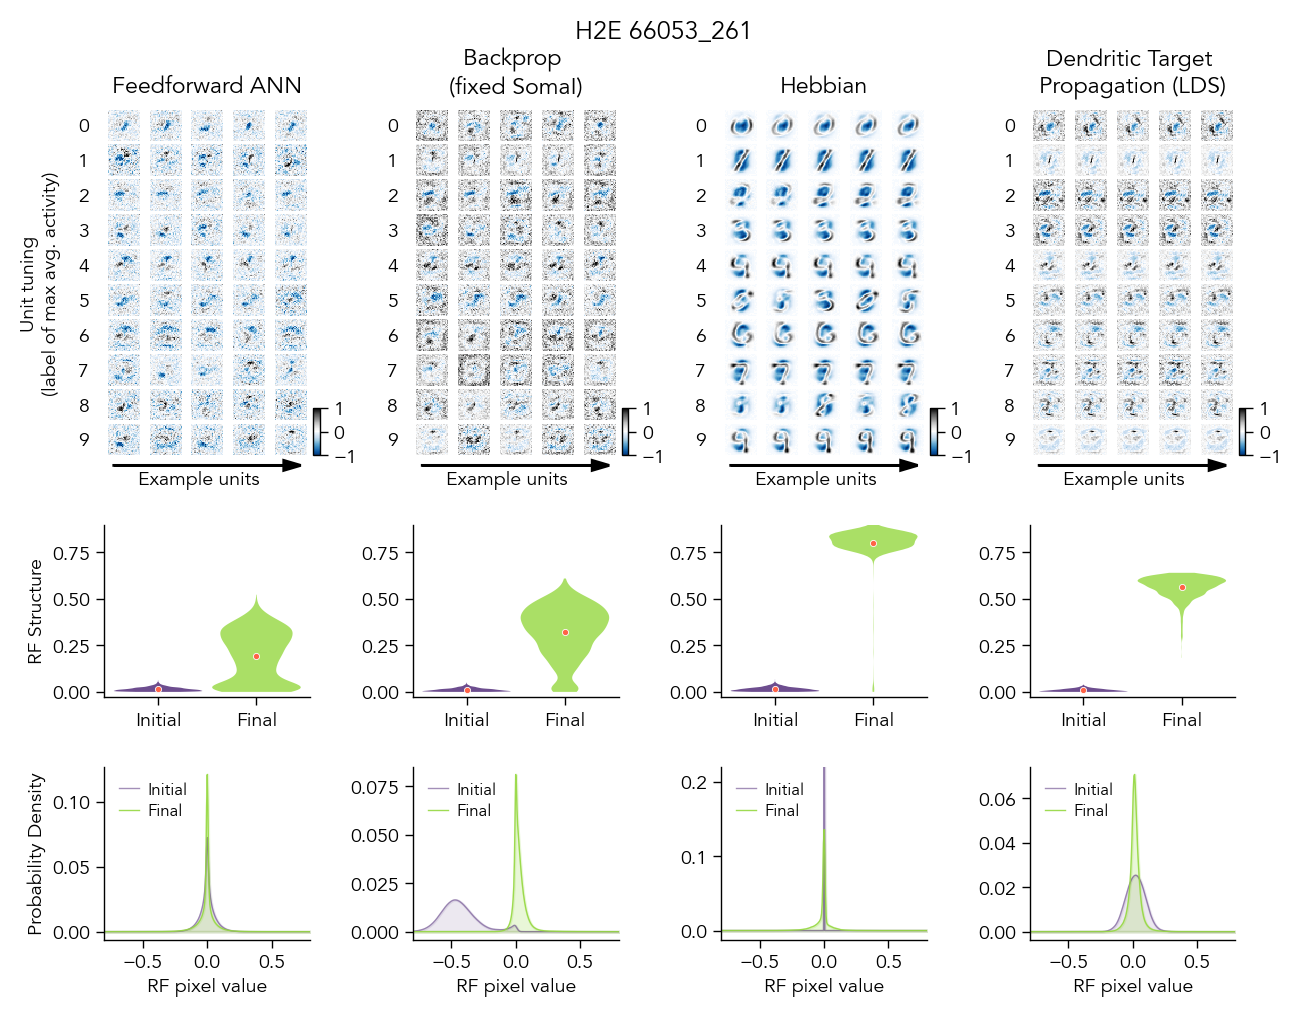

In [155]:
super_rf = {}


fig = plt.figure(figsize=(6.5, 5))
axes = gs.GridSpec(nrows=3, ncols=4, figure=fig,
                    left=0.07,right=0.94,
                    top=0.93, bottom = 0.1,
                    wspace=0.5, hspace=0.3,
                    height_ratios=[2,1,1])

if "bpLike_WT_hebbdend" in model_dict_all: # Update model label for this figure
    model_dict_all["bpLike_WT_hebbdend"]["display_name"] = "Dendritic Target \nPropagation (LDS)"
    
for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['display_name']}, population: {population}")
        example_seed = model_dict['seeds'][-1] # example seed to plot
        
        fig.suptitle(f"{population} {example_seed}", fontsize=9, x=0.5, y=1.02)

        ###########################
        # Example receptive fields
        ###########################
        receptive_fields = torch.tensor(np.array(data_dict[example_seed][f"final_receptive_fields"][population]))
        num_units = 50
        temp_ax = fig.add_subplot(axes[0, col])
        pos = temp_ax.get_position()
        
        rf_axes = fig.add_gridspec(10,5,left=pos.x0, right=pos.x1, bottom=pos.y0, top=pos.y1, wspace=0.1, hspace=0.1)
        ax_list = []
        for j in range(num_units):
            _ax = fig.add_subplot(rf_axes[j])
            ax_list.append(_ax)
            
        average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
        preferred_classes = np.argmax(average_pop_activity_dict[population], axis=0)
        im = pt.plot_receptive_fields(receptive_fields, sort=True, ax_list=ax_list, preferred_classes=preferred_classes, class_labels=False)
        height = _ax.get_position().y1 - _ax.get_position().y0
        width = _ax.get_position().x1 - _ax.get_position().x0
        cax = fig.add_axes([_ax.get_position().x1+width/5, _ax.get_position().y0, width/5, 1.5*height])
        fig.colorbar(im, cax=cax, orientation='vertical')
        ax_list[2].set_title(model_dict["display_name"])
        for label in range(10):
            temp_ax.text(-0.1, label*0.101+0.04, str(9-label), fontsize=7, ha='center', va='center')
        if col==0:
            temp_ax.set_title('Unit tuning\n(label of max avg. activity)', x=-0.31, rotation=90, y=0.45, ha='center', va='center', fontsize=7)
        temp_ax.axis('off')

        # Draw an arrow below the x-axis
        new_ax = fig.add_axes([temp_ax.get_position().x0, temp_ax.get_position().y0-0.035, temp_ax.get_position().x1-temp_ax.get_position().x0, 0.05])
        new_ax.set_ylim(-0.5, 0.5)
        new_ax.axis('off')
        new_ax.arrow(0, 0, 1, 0, head_width=0.2, head_length=0.1, facecolor='k', edgecolor='k', linewidth=1)     
        new_ax.text(0.5, -0.3, "Example units", fontsize=7, ha='center', va='center')                          

        ###############################
        # RF quantification: structure
        ###############################
        ax_structure = fig.add_subplot(axes[1, col])
        # structure_initial = np.array(data_dict[example_seed]['metrics_dict']['H1E']['structure_initial'][:]).flatten()
        # structure_final = np.array(data_dict[example_seed]['metrics_dict']['H1E']['structure_final'][:]).flatten()
        # error_initial = np.std(structure_initial)
        # error_final = np.std(structure_final)
        # ax_structure.bar(0, np.mean(structure_initial), yerr=error_initial, color=model_dict['color'], label='Initial', alpha=0.6)
        # ax_structure.bar(1, np.mean(structure_final), yerr=error_final, color=model_dict['color'], label='Final', alpha=0.6)
        # ax_structure.set_ylabel('Structure')
        # ax_structure.set_ylim(0, 1)
        # ax_structure.set_xticks([0, 1])
        # ax_structure.set_xticklabels(['Initial', 'Final'])

        # populations_to_plot = [population for population in data_dict[example_seed]['average_pop_activity_dict'] if 'DendI' in population]
        # populations_to_plot = ['H1E']
        # plot_metric_all_seeds_old(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_structure, metric_name='structure_initial', plot_type='violin')
        # plot_metric_all_seeds_old(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_structure, metric_name='structure_final', plot_type='violin')

        structure_all_seeds = {'initial': [], 'final': []}
        for seed in data_dict:
            structure_all_seeds['initial'].append(data_dict[seed][f"metrics_dict"][population]['structure_initial'][:].flatten())
            structure_all_seeds['final'].append(data_dict[seed][f"metrics_dict"][population]['structure_final'][:].flatten())
        mean_initial = np.mean(structure_all_seeds['initial'], axis=1)
        mean_final = np.mean(structure_all_seeds['final'], axis=1)
        structure_all_seeds['initial'] = np.array(structure_all_seeds['initial']).flatten()
        structure_all_seeds['final'] = np.array(structure_all_seeds['final']).flatten()

        # Create violin plot with initial and final distributions
        parts = ax_structure.violinplot([structure_all_seeds['initial'], structure_all_seeds['final']], positions=[0, 1], 
                                        showmeans=False, showmedians=False, showextrema=False, widths=0.9, side='both')
        parts['bodies'][0].set_alpha(0.8)
        parts['bodies'][0].set_facecolor("#482173")
        parts['bodies'][1].set_alpha(0.8)
        parts['bodies'][1].set_facecolor("#95D840FF")        
        ax_structure.set_xticks([0, 1])
        ax_structure.set_xticklabels(['Initial', 'Final'])

        # Scatter on a point with the mean and error bar
        initial_mean = np.mean(mean_initial)
        final_mean = np.mean(mean_final)
        ax_structure.scatter(0, initial_mean, color='tomato', marker='o', s=5, zorder=5, edgecolors='w', linewidth=0.3)
        ax_structure.scatter(1, final_mean, color='tomato', marker='o', s=5, zorder=5, edgecolors='w', linewidth=0.3)
        # initial_error = np.std(mean_initial)
        # final_error = np.std(mean_final)
        # ax_structure.errorbar(0, initial_mean, yerr=initial_error, color='k', fmt='none', capsize=2, capthick=0.5, zorder=5)
        # ax_structure.errorbar(1, final_mean, yerr=final_error, color='k', fmt='none', capsize=2, capthick=0.5, zorder=5)
        ax_structure.set_ylim(-0.03, 0.9)
        if col == 0:
            ax_structure.set_ylabel('RF Structure')

        ###############################
        # RF quantification: pixel KDE
        ###############################
        
        ax_hist = fig.add_subplot(axes[2, col])
        initial_receptive_fields = []
        final_receptive_fields = []
        for seed in data_dict:
            initial_receptive_fields.append(data_dict[seed]['initial_receptive_fields'][population][:])
            final_receptive_fields.append(data_dict[seed]['final_receptive_fields'][population][:])
        initial_receptive_fields = np.array(initial_receptive_fields)
        final_receptive_fields = np.array(final_receptive_fields)

        super_rf[model_key] = {'initial': initial_receptive_fields, 'final': final_receptive_fields}

        # Normalize pixel values
        max_pixel_value = np.max([np.abs(initial_receptive_fields), np.abs(final_receptive_fields)])
        initial_receptive_fields = initial_receptive_fields / max_pixel_value
        final_receptive_fields = final_receptive_fields / max_pixel_value
        
        # Create KDE plots
        x_range = np.concatenate([np.linspace(-1, -1e-12, 200), np.linspace(0, 1, 200)])
        initial_kde = scipy.stats.gaussian_kde(initial_receptive_fields.flatten(), bw_method=0.1)
        initial_density = initial_kde(x_range)        
        final_kde = scipy.stats.gaussian_kde(final_receptive_fields.flatten(), bw_method=0.1)
        final_density = final_kde(x_range)
        initial_density = initial_density / np.sum(initial_density)
        final_density = final_density / np.sum(final_density)
        
        # Plot KDE curves
        ax_hist.plot(x_range, initial_density, color='#482173', label='Initial', alpha=0.5, linewidth=0.5)
        ax_hist.fill_between(x_range, initial_density, alpha=0.1, color='#482173')
        ax_hist.plot(x_range, final_density, color='#95D840FF', label='Final', alpha=0.9, linewidth=0.5)
        ax_hist.fill_between(x_range, final_density, alpha=0.2, color='#95D840FF')

        # ax_hist.plot(x_range, initial_density, color='darkblue', label='Initial', alpha=0.5, linewidth=0.5)
        # ax_hist.fill_between(x_range, initial_density, alpha=0.1, color='darkblue')
        # ax_hist.plot(x_range, final_density, color='orange', label='Final', alpha=0.9, linewidth=0.5)
        # ax_hist.fill_between(x_range, final_density, alpha=0.2, color='orange')

        ax_hist.legend(loc='upper left', fontsize=6)
        ax_hist.set_xlabel('RF pixel value')
        if col == 0:
            ax_hist.set_ylabel('Probability Density')

        # ax_hist.set_xlim([-0.5, 0.5])
        # ylim = ax_hist.get_ylim()
        # if ylim[1] > 0.3:
        #     ax_hist.set_ylim([-0.012, 0.25])

        ax_hist.set_xlim([-0.8, 0.8])
        ylim = ax_hist.get_ylim()
        if ylim[1] > 0.3:
            ax_hist.set_ylim([-0.012, 0.22])

        # ### Histogram ###
        # populations_to_plot = ['H1E']
        # ax_hist = fig.add_subplot(axes[2, col])
        # initial_receptive_fields = []
        # final_receptive_fields = []
        # for seed in data_dict:
        #     for population in populations_to_plot:
        #         initial_receptive_fields.append(data_dict[seed]['initial_receptive_fields'][population][:])
        #         final_receptive_fields.append(data_dict[seed]['final_receptive_fields'][population][:])
        # initial_receptive_fields = np.array(initial_receptive_fields)
        # final_receptive_fields = np.array(final_receptive_fields)
        
        # # Normalize pixel values
        # max_pixel_value = np.max([np.abs(initial_receptive_fields), np.abs(final_receptive_fields)])
        # initial_receptive_fields = initial_receptive_fields / max_pixel_value
        # final_receptive_fields = final_receptive_fields / max_pixel_value
        
        # bin_width = 0.03
        # bins = np.arange(-1, 1, bin_width)
        # initial_hist, _ = np.histogram(initial_receptive_fields.flatten(), bins=bins, density=False)
        # ax_hist.bar(bins[:-1], initial_hist, width=bin_width, color='blue', label='Initial', alpha=0.3)       
        # final_hist, _ = np.histogram(final_receptive_fields.flatten(), bins=bins, density=False)
        # ax_hist.bar(bins[:-1], final_hist, width=bin_width, color='orange', label='Final', alpha=0.4)
        
        # # Add horizontal line at zero
        # # ax_hist.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.8)
        # ax_hist.set_xlim(-0.5, 0.5)
        # ax_hist.set_ylim(bottom=-1e3)
        # ax_hist.legend()
        # ax_hist.set_xlabel('RF pixel value')
        # if col == 0:
        #     ax_hist.set_ylabel('Number of pixels')

fig.savefig(root_dir + f"/EIANN/figures/{figure_name}_{population}.png", dpi=300)
fig.savefig(root_dir + f"/EIANN/figures/{figure_name}_{population}.svg", dpi=300)


In [156]:
super_rf.keys()

dict_keys(['vanBP', 'bpDale_fixed', 'HebbWN_topsup', 'bpLike_WT_hebbdend'])

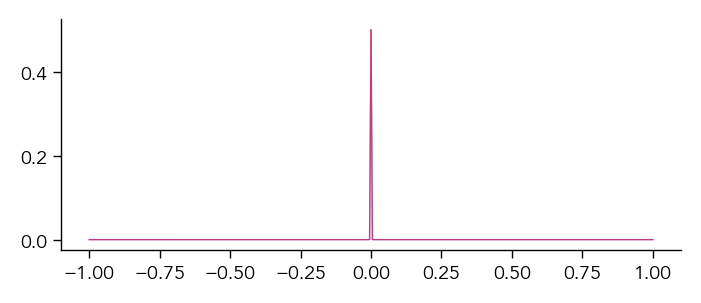

In [159]:
initial = super_rf['HebbWN_topsup']['initial']
final = super_rf['HebbWN_topsup']['final']

# plt.hist(initial, bins=100, color='blue', alpha=0.5)
# plt.hist(final, bins=100, color='red', alpha=0.5)
# plt.show()

# Create KDE plots
x_range = np.concatenate([np.linspace(-1, -1e-12, 200), np.linspace(0, 1, 200)])
initial_kde = scipy.stats.gaussian_kde(initial.flatten(), bw_method=0.1)
initial_density = initial_kde(x_range)        
final_kde = scipy.stats.gaussian_kde(final.flatten(), bw_method=0.1)
final_density = final_kde(x_range)
initial_density = initial_density / np.sum(initial_density)
final_density = final_density / np.sum(final_density)

plt.plot(x_range, initial_density, color='blue', label='Initial', alpha=0.5)
plt.plot(x_range, final_density, color='red', label='Final', alpha=0.5)
plt.show()